# Gaussian Naive Bayes - Diabetes Classification

This notebook implements the Gaussian Naive Bayes (GNB) algorithm for the diabetes classification problem.

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load the dataset
df = pd.read_csv("../dataset/diabetes_prediction_dataset_2000.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0,0,No Info,20.82,5.8,126,0
1,Female,3.0,0,0,No Info,21.00,5.0,145,0
2,Male,63.0,0,0,former,25.32,3.5,200,0
3,Female,2.0,0,0,never,17.43,6.1,126,0
4,Female,33.0,0,0,not current,40.08,6.2,200,1


In [3]:
# Basic dataset checking
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (2000, 9)

Columns:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicate rows: 4


In [4]:
# Removing duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

Rows before removing duplicates: 2000
Duplicate rows removed: 4
Rows after removing duplicates: 1996


In [5]:
# Checking missing values
missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values were found.")
else:
    numerical_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

    print("Missing values were handled using median imputation for numerical columns and mode imputation for categorical columns.")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

No missing values were found.

Missing values after cleaning:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [6]:
# Diabetes class distribution
print("Diabetes counts:")
print(df["diabetes"].value_counts())

print("\nPercentage of each class:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

Diabetes counts:
diabetes
0    1831
1     165
Name: count, dtype: int64

Percentage of each class:
diabetes
0    91.73
1     8.27
Name: proportion, dtype: float64


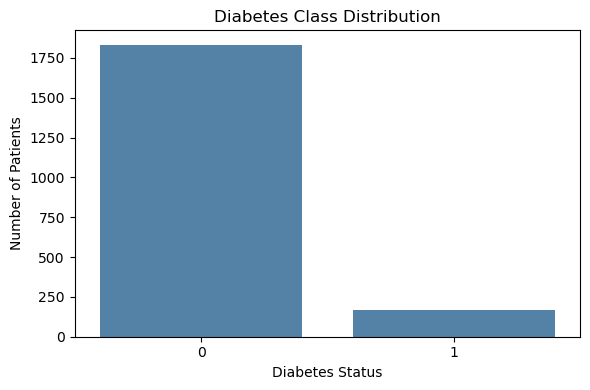

In [7]:
# Diabetes class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diabetes", color="steelblue")
plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

The target distribution shows how many patients belong to each diabetes class. The two classes are not equally represented, so the class distribution should be considered when interpreting the classification results.

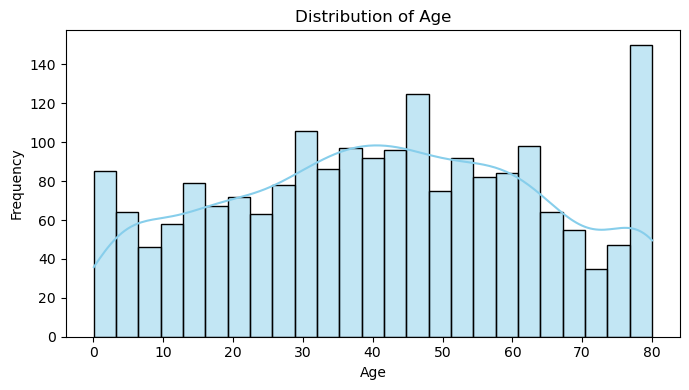

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(df["age"], bins=25, kde=True, color="skyblue")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The age distribution shows how the patients are spread across different age groups. It helps identify the main age range represented in the dataset and whether the values are concentrated or spread out.

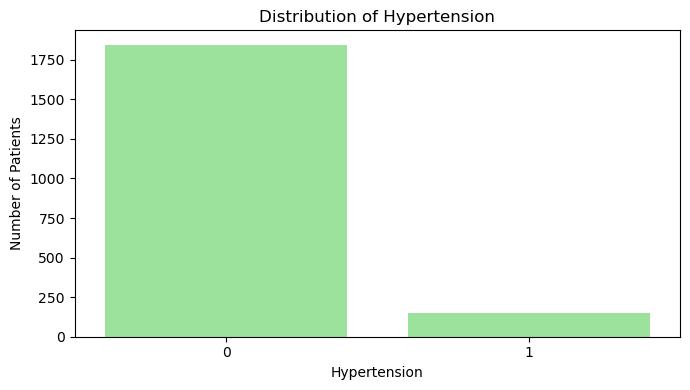

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="hypertension", color="lightgreen")
plt.title("Distribution of Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

Hypertension is a binary health indicator where 0 represents patients without hypertension and 1 represents patients with hypertension. A count plot clearly compares the frequency of the two values. The plot shows that most patients have a value of 0.

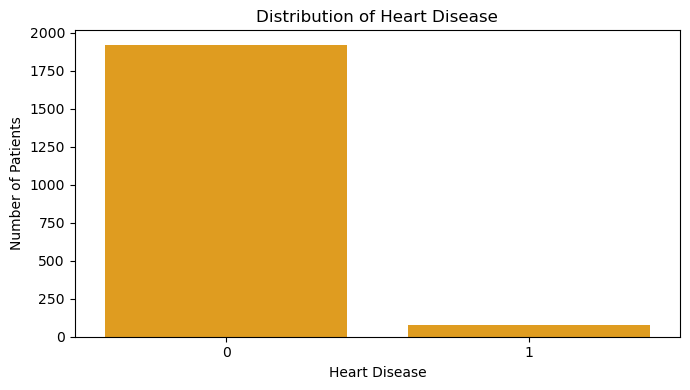

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="heart_disease", color="orange")
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Insight

Heart disease is a binary health indicator. The count plot shows the number of patients in each category and helps identify whether one of the two values is more common.

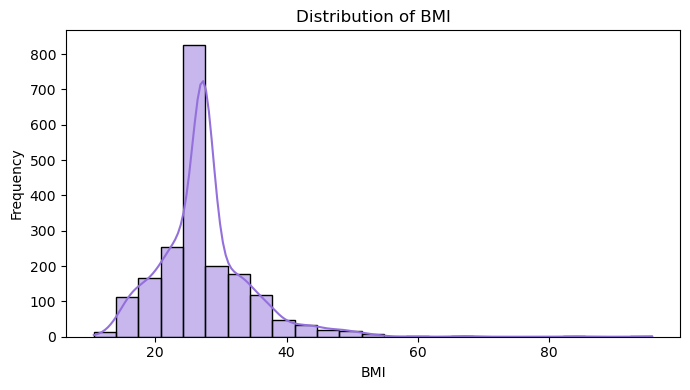

In [11]:
plt.figure(figsize=(7, 4))
sns.histplot(df["bmi"], bins=25, kde=True, color="mediumpurple")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The BMI distribution shows the range and concentration of body-mass values among the patients. It also helps identify the overall spread of this numerical feature.

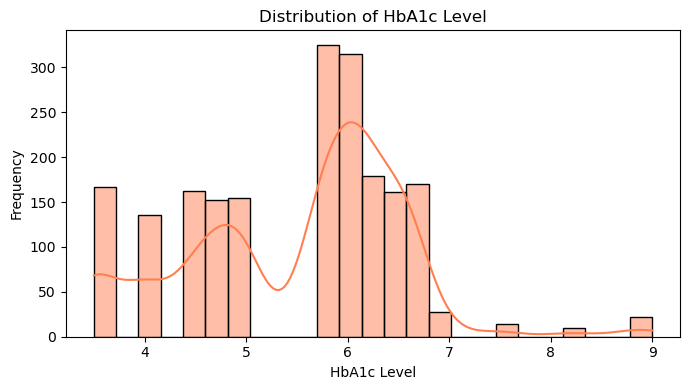

In [12]:
plt.figure(figsize=(7, 4))
sns.histplot(df["HbA1c_level"], bins=25, kde=True, color="coral")
plt.title("Distribution of HbA1c Level")
plt.xlabel("HbA1c Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The HbA1c distribution shows how the measured HbA1c values vary among the patients. The spread of this feature is useful when examining its relationship with the diabetes target.

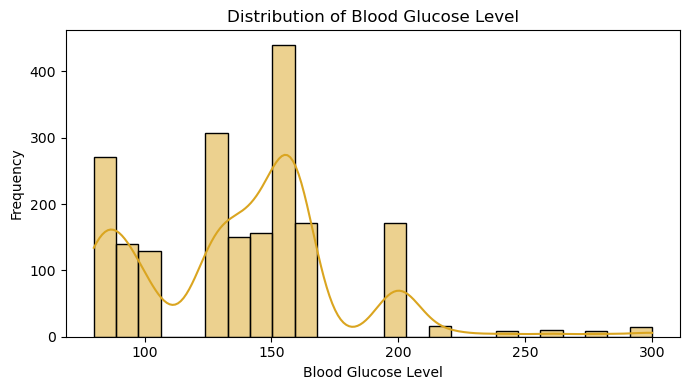

In [13]:
plt.figure(figsize=(7, 4))
sns.histplot(df["blood_glucose_level"], bins=25, kde=True, color="goldenrod")
plt.title("Distribution of Blood Glucose Level")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Insight

The blood glucose distribution shows the range and frequency of glucose measurements. This feature can provide useful information for distinguishing the diabetes classes.

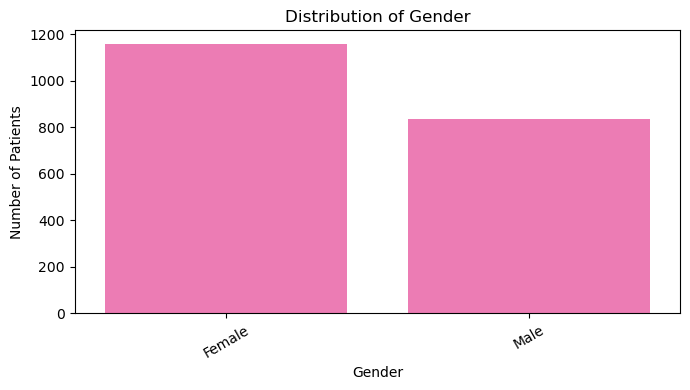

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="gender", color="hotpink")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

The gender distribution shows how the patient records are divided among the available gender categories. It helps identify whether one category is more common in the dataset.

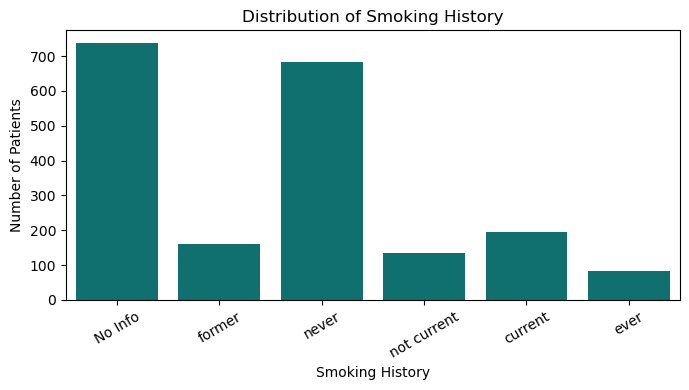

In [15]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="smoking_history", color="teal")
plt.title("Distribution of Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Number of Patients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

The smoking-history distribution shows the number of patients in each smoking category. This gives an overview of the categorical feature before it is encoded for model training.

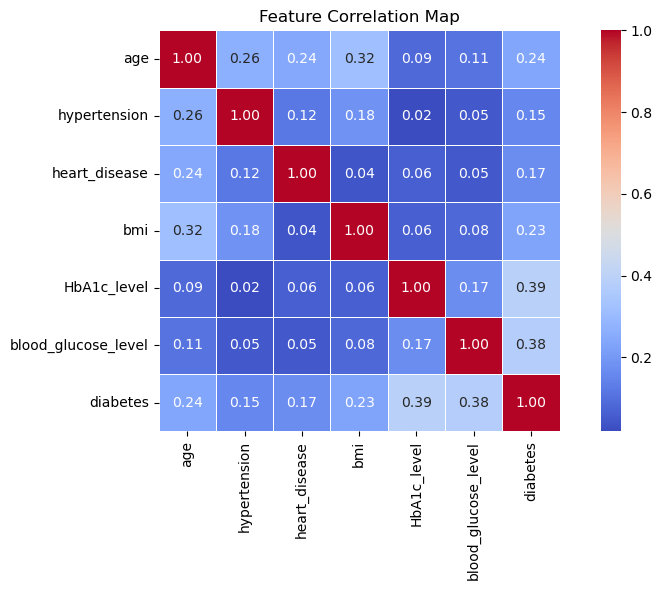

In [16]:
# Correlation heatmap
num_cols = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

corr = df[num_cols + ["diabetes"]].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.6,
    square=True
)
plt.title("Feature Correlation Map")
plt.tight_layout()
plt.show()

### Insight

The correlation heatmap shows the linear relationships among the numerical features and the diabetes target. It helps identify features with stronger or weaker linear relationships with the target and also shows relationships between the input features themselves.

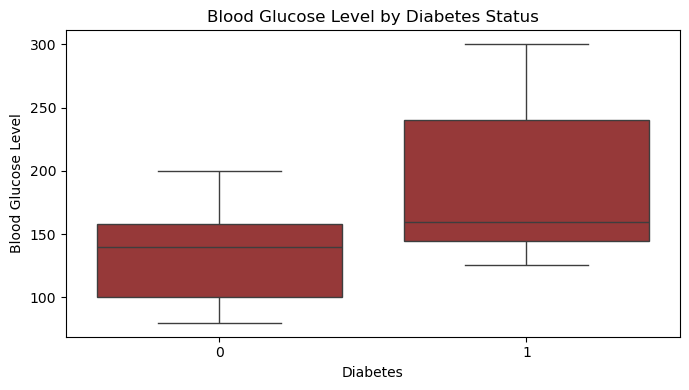

In [17]:
# Blood glucose level by diabetes status
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="diabetes",
    y="blood_glucose_level",
    color="brown"
)
plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("Blood Glucose Level")
plt.tight_layout()
plt.show()

### Insight

The boxplot compares blood glucose levels between the two diabetes classes. Differences in the central values and spread between the groups indicate that blood glucose level may provide useful information for distinguishing the target classes.

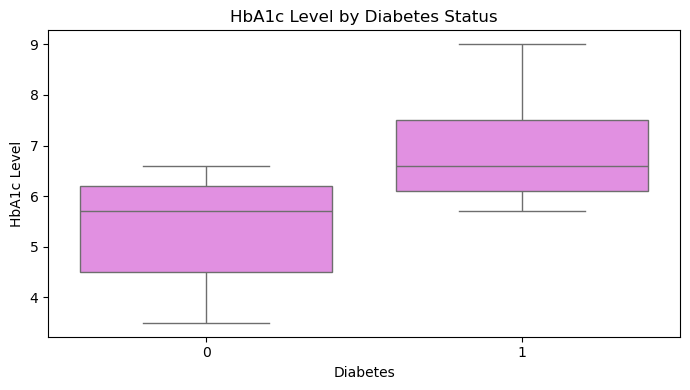

In [18]:
# HbA1c level by diabetes status
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="diabetes",
    y="HbA1c_level",
    color="violet"
)
plt.title("HbA1c Level by Diabetes Status")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")
plt.tight_layout()
plt.show()

### Insight

The HbA1c boxplot compares the distribution of HbA1c values between patients with and without diabetes. Differences between the two groups show that this feature may help separate the target classes.

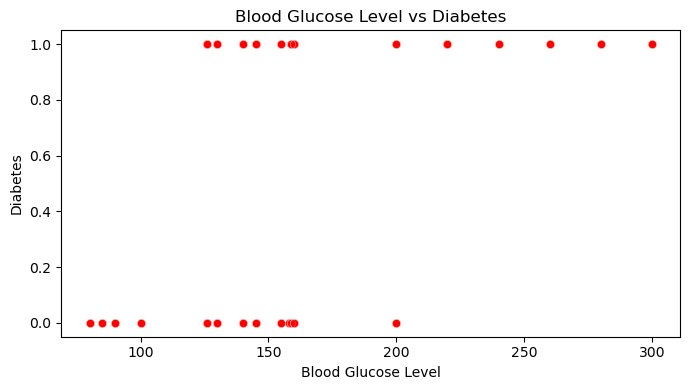

In [19]:
# Scatter plot: Blood glucose vs diabetes
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="blood_glucose_level",
    y="diabetes",
    alpha=0.45,
    color="red"
)
plt.title("Blood Glucose Level vs Diabetes")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows how the diabetes labels are distributed across blood glucose levels. The distribution of points across the two classes gives a visual indication of how useful blood glucose level may be for distinguishing diabetes status.

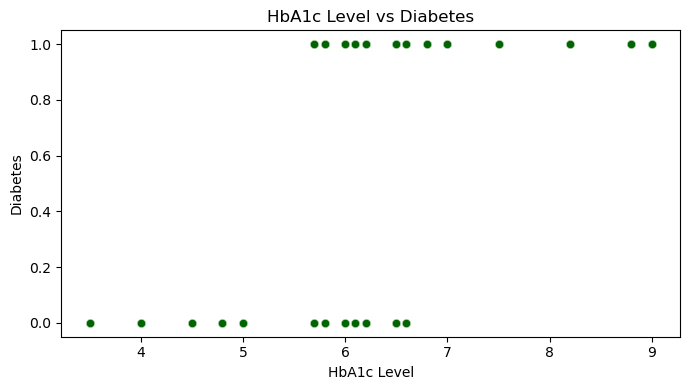

In [20]:
# Scatter plot: HbA1c vs diabetes
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="HbA1c_level",
    y="diabetes",
    alpha=0.45,
    color="darkgreen"
)
plt.title("HbA1c Level vs Diabetes")
plt.xlabel("HbA1c Level")
plt.ylabel("Diabetes")
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows the distribution of diabetes labels across different HbA1c levels. The pattern of the points provides a visual indication of whether HbA1c level can help separate the two target classes.

In [21]:
# Check and treat outliers using the IQR method
outlier_cols = [
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers Found": count
    })

    df[col] = df[col].clip(lower=lower, upper=upper)

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Feature,Lower Bound,Upper Bound,Outliers Found
0,bmi,14.66375,38.61375,143
1,HbA1c_level,2.70000,8.30000,22
2,blood_glucose_level,11.50000,247.50000,33


In [22]:
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    remaining = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "Outliers After Treatment:", remaining)

bmi Outliers After Treatment: 0
HbA1c_level Outliers After Treatment: 0
blood_glucose_level Outliers After Treatment: 0


In [23]:
# Create an engineered feature
df["glucose_hba1c_interaction"] = (
    df["blood_glucose_level"] * df["HbA1c_level"]
)

print("Engineered feature created: glucose_hba1c_interaction")

df[
    [
        "blood_glucose_level",
        "HbA1c_level",
        "glucose_hba1c_interaction"
    ]
].head()

Engineered feature created: glucose_hba1c_interaction


,blood_glucose_level,HbA1c_level,glucose_hba1c_interaction
0,126.0,5.8,730.8
1,145.0,5.0,725.0
2,200.0,3.5,700.0
3,126.0,6.1,768.6
4,200.0,6.2,1240.0


In [24]:
# Separating features and target
x = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (1996, 9)
Target shape: (1996,)


In [25]:
# Stratified train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data: (1596, 9)
Testing data: (400, 9)

Training target distribution:
diabetes
0    0.917
1    0.083
Name: proportion, dtype: float64

Testing target distribution:
diabetes
0    0.918
1    0.082
Name: proportion, dtype: float64


In [26]:
# Preprocessing method
num_features = [
    "age",
    "hypertension",
    "heart_disease",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level",
    "glucose_hba1c_interaction"
]

cat_features = [
    "gender",
    "smoking_history"
]

prep = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_features),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features
        )
    ]
)

In [27]:
# Building the Gaussian Naive Bayes model
nb_model = Pipeline(
    steps=[
        ("preprocessing", prep),
        ("naive_bayes", GaussianNB())
    ]
)

In [28]:
# Training the Gaussian Naive Bayes model
nb_model.fit(x_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [29]:
# Making predictions
nb_pred = nb_model.predict(x_test)
nb_prob = nb_model.predict_proba(x_test)[:, 1]

print("First 10 Naive Bayes predictions:")
print(nb_pred[:10])

First 10 Naive Bayes predictions:
[0 0 0 0 1 0 0 0 0 0]


In [30]:
# Calculating evaluation metrics
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, zero_division=0)
nb_recall = recall_score(y_test, nb_pred, zero_division=0)
nb_f1 = f1_score(y_test, nb_pred, average="weighted")
nb_auc = roc_auc_score(y_test, nb_prob)

print("Gaussian Naive Bayes Classification Results")
print("-------------------------------------------")
print("Accuracy    :", nb_accuracy)
print("Precision   :", nb_precision)
print("Recall      :", nb_recall)
print("Weighted F1 :", nb_f1)
print("ROC-AUC     :", nb_auc)

Gaussian Naive Bayes Classification Results
-------------------------------------------
Accuracy    : 0.9
Precision   : 0.43859649122807015
Recall      : 0.7575757575757576
Weighted F1 : 0.9116431924882629
ROC-AUC     : 0.9355957394104533


In [31]:
# Classification report
print(
    classification_report(
        y_test,
        nb_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.98      0.91      0.94       367
           1       0.44      0.76      0.56        33

    accuracy                           0.90       400
   macro avg       0.71      0.84      0.75       400
weighted avg       0.93      0.90      0.91       400



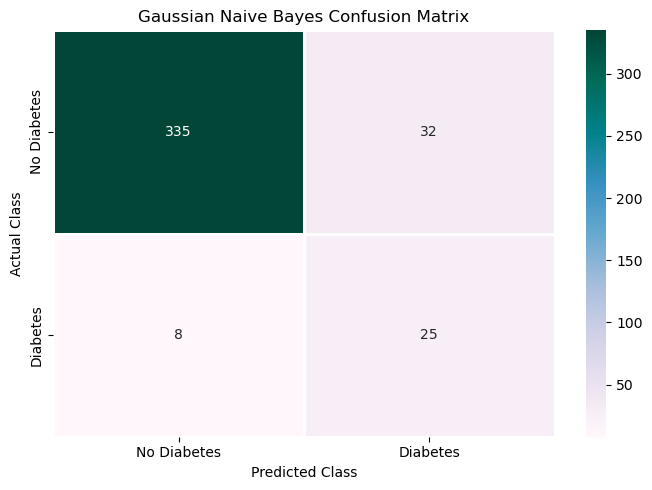

In [32]:
# Gaussian Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=1,
    linecolor="white",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

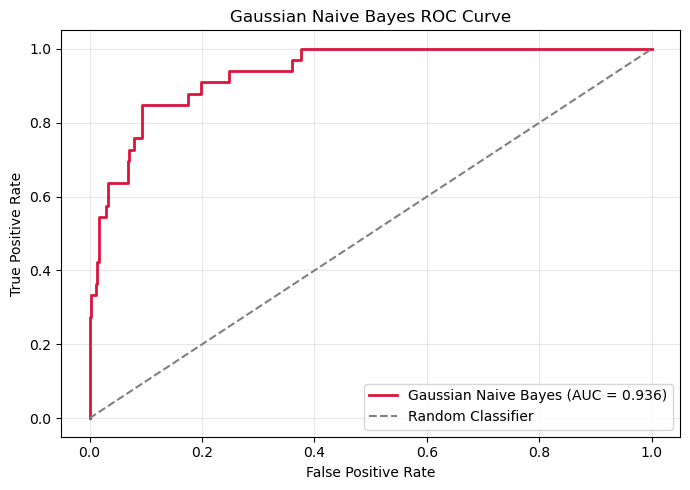

In [33]:
# ROC Curve for Gaussian Naive Bayes
fpr_nb, tpr_nb, thresholds_nb = roc_curve(
    y_test,
    nb_prob
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr_nb,
    tpr_nb,
    color="crimson",
    linewidth=2,
    label=f"Gaussian Naive Bayes (AUC = {nb_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gaussian Naive Bayes ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
import os
import pandas as pd

results_path = "../results/classification_results.csv"

gnb_row = pd.DataFrame([{
    "Model": "Gaussian Naive Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "Weighted F1": nb_f1,
    "ROC-AUC": nb_auc
}])

if os.path.exists(results_path):
    results = pd.read_csv(results_path)
    results = results[results["Model"] != "Gaussian Naive Bayes"]
    results = pd.concat([results, gnb_row], ignore_index=True)
else:
    results = gnb_row

results.to_csv(results_path, index=False)

results = pd.read_csv(results_path)

results = results[results["Model"].isin([
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Gaussian Naive Bayes"
])]

results.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.945,0.761905,0.484848,0.939331,0.943522
1,K-Nearest Neighbors,0.955,0.894737,0.515152,0.949363,0.868095
2,Gaussian Naive Bayes,0.900,0.438596,0.757576,0.911643,0.935596
